In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [78]:
# data = {
#     'Tahun': [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
#     'Sosial': [24640, 27975, 31843, 26959, 141352, 157611, 186626, 185225, 59503, 62072],
#     'Rumah Tangga': [653467, 730450, 774804, 704418, 3098139, 3411916, 3680989, 4050452, 1596271, 1517952],
#     'Bisnis': [117830, 114459, 134813, 149497, 1375627, 1510029, 1930786, 1789882, 186721, 313643],
#     'Industri': [4691520, 4742550, 4781701, 5003347, 4937351, 10962941, 11471663, 12353842, 7393955, 6171390],
#     'Lainnya': [32017, 45083, 61247, 53047, 246033, 250567, 411889, 511336, 640704, 326378],
#     'Jumlah': [5519473, 5661236, 5784408, 5940219, 14298502, 16293265, 17682053, 18890594, 9833522, 8391435]
# }

In [79]:
# df = pd.DataFrame(data)

df = pd.read_csv("energi.csv")

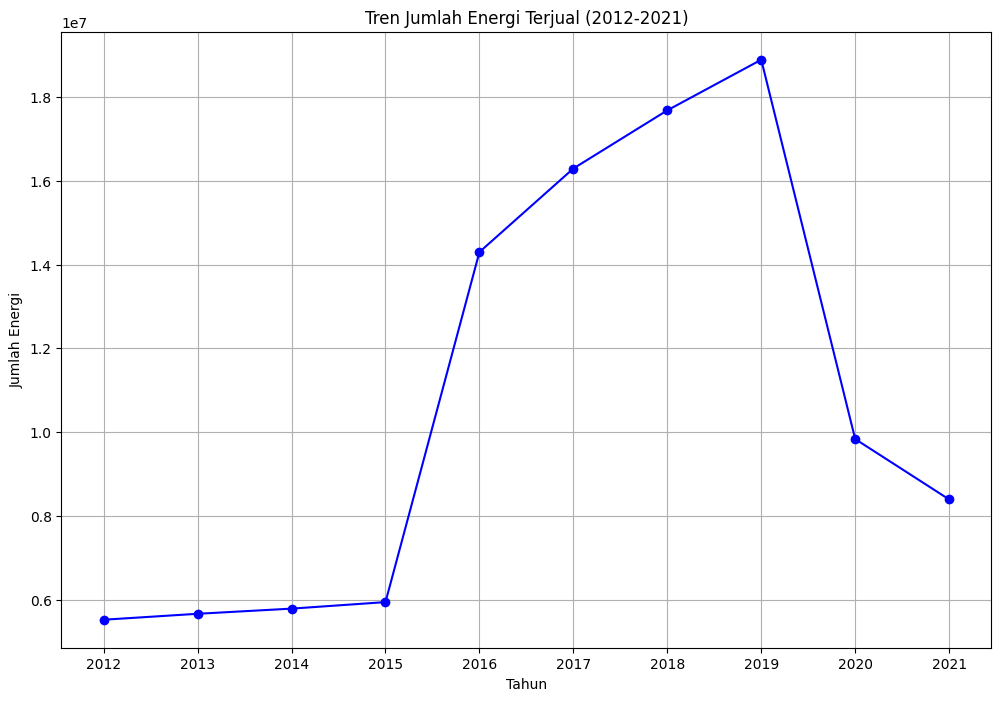

In [80]:
plt.figure(figsize=(12, 8))
plt.plot(df['Tahun'], df['Jumlah'], marker='o', linestyle='-', color='blue')
plt.title('Tren Jumlah Energi Terjual (2012-2021)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Energi')
plt.grid(True)
plt.xticks(df['Tahun'])
plt.show()

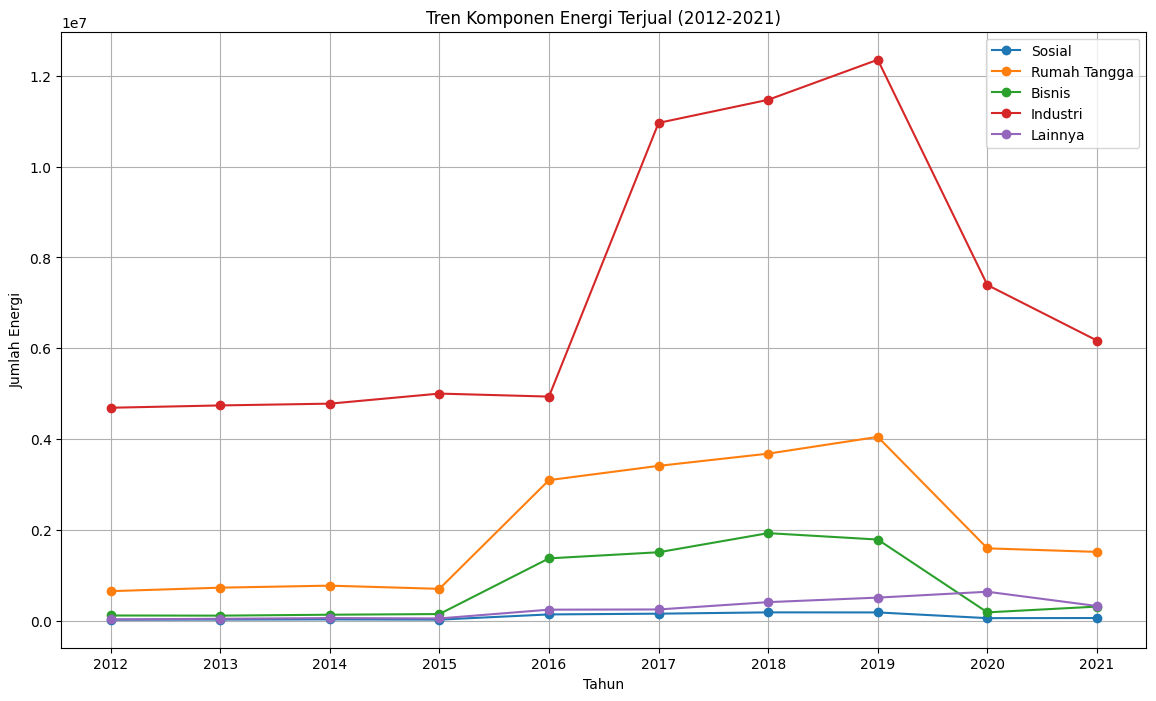

In [81]:
plt.figure(figsize=(14, 8))
categories = ['Sosial', 'Rumah Tangga', 'Bisnis', 'Industri', 'Lainnya']
for category in categories:
    plt.plot(df['Tahun'], df[category], marker='o', linestyle='-', label=category)
plt.title('Tren Komponen Energi Terjual (2012-2021)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Energi')
plt.grid(True)
plt.xticks(df['Tahun'])
plt.legend()
plt.show()

In [82]:
X = df['Tahun'].values.reshape(-1, 1)
y = df['Jumlah'].values

In [83]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [84]:
tahun_prediksi = np.array([[2022], [2023], [2024]])
prediksi_jumlah = model.predict(tahun_prediksi)

In [85]:
hasil_prediksi = pd.DataFrame({
    'Tahun': [2022, 2023, 2024],
    'Prediksi Jumlah': prediksi_jumlah
})
print("Hasil Prediksi Jumlah Energi Terjual:")
print(hasil_prediksi)

Hasil Prediksi Jumlah Energi Terjual:
   Tahun  Prediksi Jumlah
0   2022     1.608963e+07
1   2023     1.704603e+07
2   2024     1.800242e+07


In [ ]:
pd.options.display.float_format = '{:,.0f}'.format

print(hasil_prediksi.head(13))

   Tahun  Prediksi Jumlah
0   2022       16,089,633
1   2023       17,046,026
2   2024       18,002,419


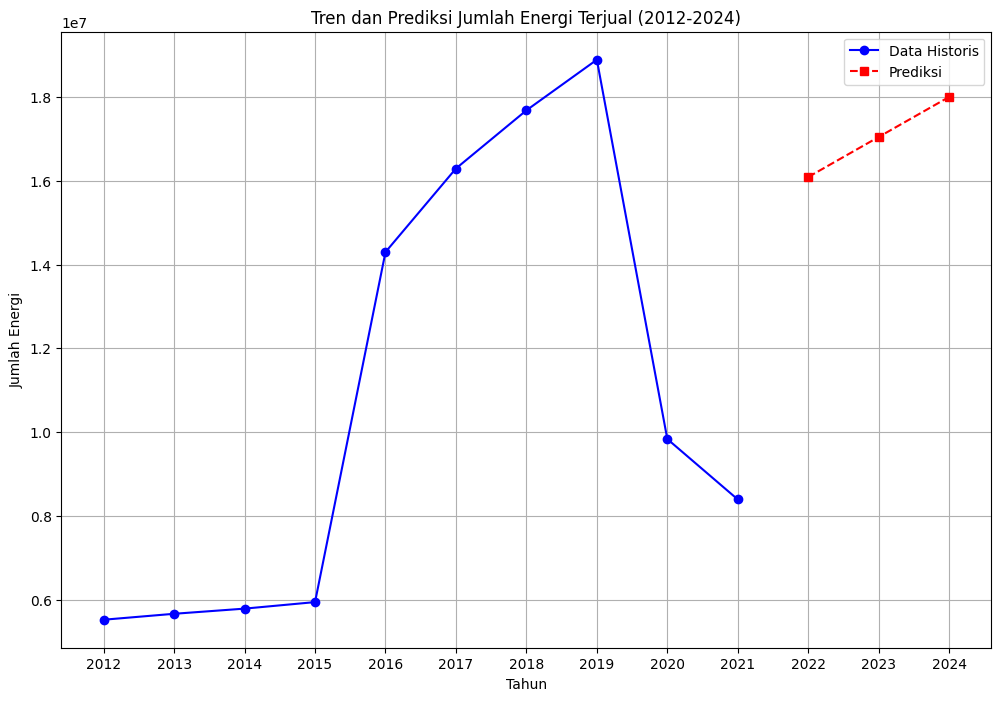

In [86]:
plt.figure(figsize=(12, 8))
plt.plot(df['Tahun'], df['Jumlah'], marker='o', linestyle='-', color='blue', label='Data Historis')
plt.plot([2022, 2023, 2024], prediksi_jumlah, marker='s', linestyle='--', color='red', label='Prediksi')
plt.title('Tren dan Prediksi Jumlah Energi Terjual (2012-2024)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Energi')
plt.grid(True)
plt.xticks(list(df['Tahun']) + [2022, 2023, 2024])
plt.legend()
plt.show()

In [87]:
kategori_hasil = {}
for kategori in categories:
    y_kategori = df[kategori].values
    model_kategori = LinearRegression()
    model_kategori.fit(X, y_kategori)
    prediksi_kategori = model_kategori.predict(tahun_prediksi)
    kategori_hasil[kategori] = prediksi_kategori

In [88]:
hasil_kategori = pd.DataFrame({
    'Tahun': [2022, 2023, 2024]
})

for kategori in categories:
    hasil_kategori[kategori] = kategori_hasil[kategori]

In [89]:
hasil_kategori['Total Prediksi'] = hasil_kategori[categories].sum(axis=1)

print("\nHasil Prediksi per Kategori:")
print(hasil_kategori)


Hasil Prediksi per Kategori:
   Tahun         Sosial  ...        Lainnya  Total Prediksi
0   2022  151039.066667  ...  596166.800000    1.580426e+07
1   2023  162067.878788  ...  657682.563636    1.678987e+07
2   2024  173096.690909  ...  719198.327273    1.777547e+07

[3 rows x 7 columns]


In [ ]:
plt.figure(figsize=(15, 10))
tahun_lengkap = list(df['Tahun']) + [2022, 2023, 2024]

<Figure size 1500x1000 with 0 Axes>

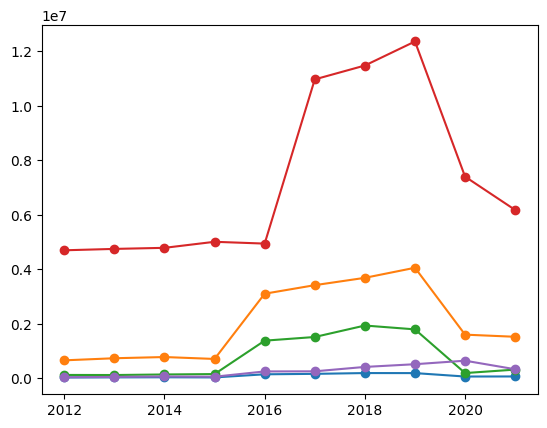

In [ ]:
for kategori in categories:
    plt.plot(df['Tahun'], df[kategori], marker='o', linestyle='-', label=f'Historis {kategori}')

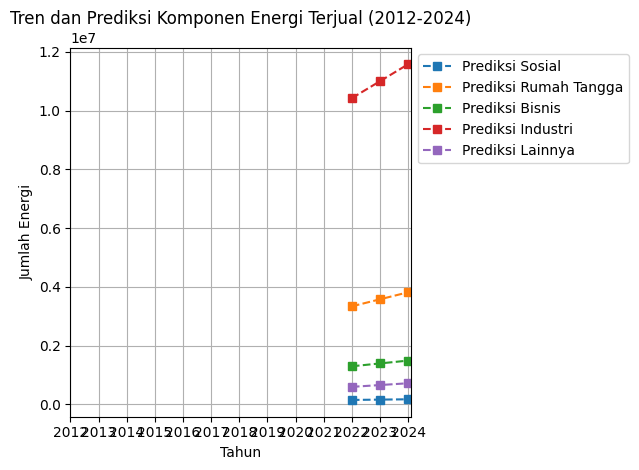

In [ ]:
for kategori in categories:
    prediksi_values = kategori_hasil[kategori]
    plt.plot([2022, 2023, 2024], prediksi_values, marker='s', linestyle='--', label=f'Prediksi {kategori}')

plt.title('Tren dan Prediksi Komponen Energi Terjual (2012-2024)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Energi')
plt.grid(True)
plt.xticks(tahun_lengkap)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nEvaluasi Model Regresi Linear untuk Total Energi:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Koefisien: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


Evaluasi Model Regresi Linear untuk Total Energi:
Mean Squared Error: 18956518243187.24
R² Score: 0.2847
Koefisien: 956393.06
Intercept: -1917737136.01


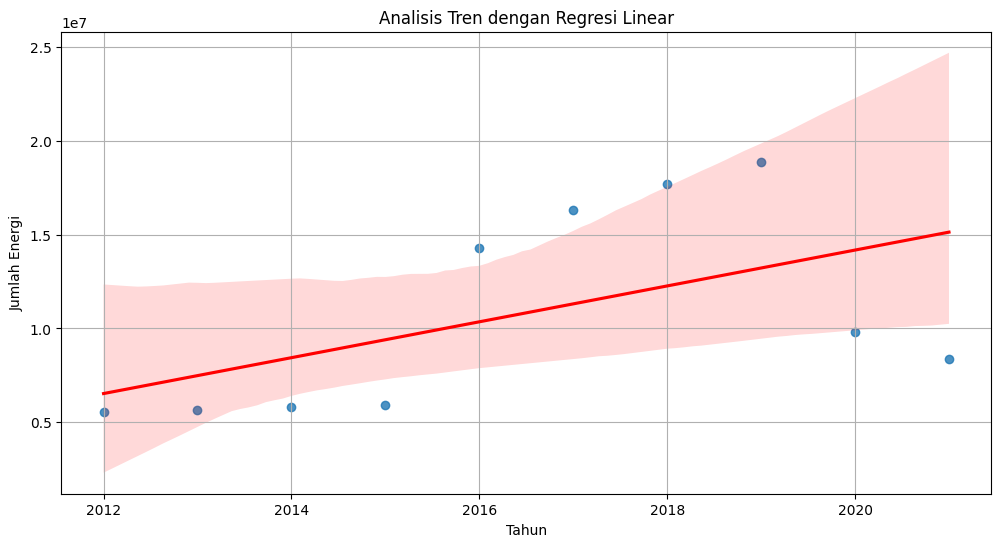

In [94]:
# Analisis tren
plt.figure(figsize=(12, 6))
sns.regplot(x='Tahun', y='Jumlah', data=df, line_kws={"color": "red"})
plt.title('Analisis Tren dengan Regresi Linear')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Energi')
plt.grid(True)
plt.show()

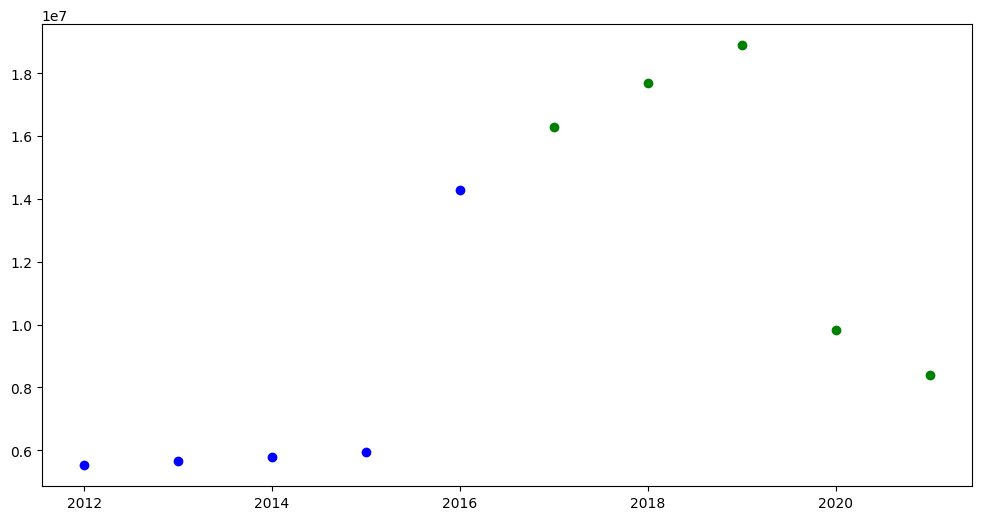

In [ ]:
df_early = df[df['Tahun'] <= 2016]
df_late = df[df['Tahun'] > 2016]

plt.figure(figsize=(12, 6))
plt.scatter(df_early['Tahun'], df_early['Jumlah'], color='blue', label='2012-2016')
plt.scatter(df_late['Tahun'], df_late['Jumlah'], color='green', label='2017-2021')

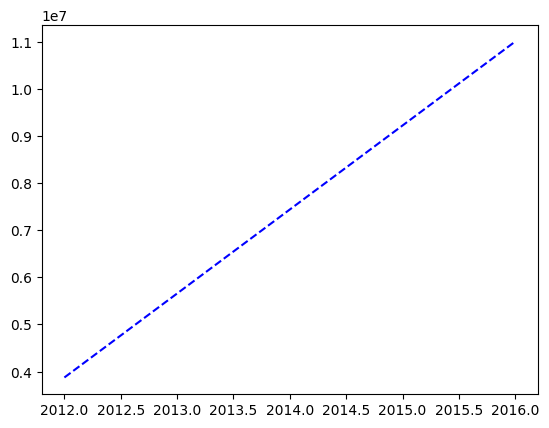

In [ ]:
model_early = LinearRegression()
model_early.fit(df_early['Tahun'].values.reshape(-1, 1), df_early['Jumlah'])
x_early = np.array([min(df_early['Tahun']), max(df_early['Tahun'])])
y_early = model_early.predict(x_early.reshape(-1, 1))
plt.plot(x_early, y_early, color='blue', linestyle='--')

C:\Users\rezaa\AppData\Local\Temp\ipykernel_648\2413176037.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


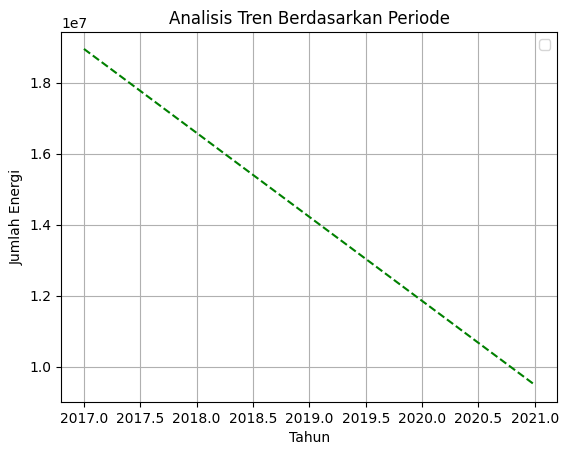

In [ ]:
model_late = LinearRegression()
model_late.fit(df_late['Tahun'].values.reshape(-1, 1), df_late['Jumlah'])
x_late = np.array([min(df_late['Tahun']), max(df_late['Tahun'])])
y_late = model_late.predict(x_late.reshape(-1, 1))
plt.plot(x_late, y_late, color='green', linestyle='--')

plt.title('Analisis Tren Berdasarkan Periode')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Energi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
tahun_pred = np.array([[2022], [2023], [2024]])
prediksi_periode_akhir = model_late.predict(tahun_pred)

print("\nPrediksi Berdasarkan Tren Periode 2017-2021:")
hasil_pred_periode = pd.DataFrame({
    'Tahun': [2022, 2023, 2024],
    'Prediksi Jumlah': prediksi_periode_akhir
})
print(hasil_pred_periode)


Prediksi Berdasarkan Tren Periode 2017-2021:
   Tahun  Prediksi Jumlah
0   2022     7.122517e+06
1   2023     4.757297e+06
2   2024     2.392078e+06


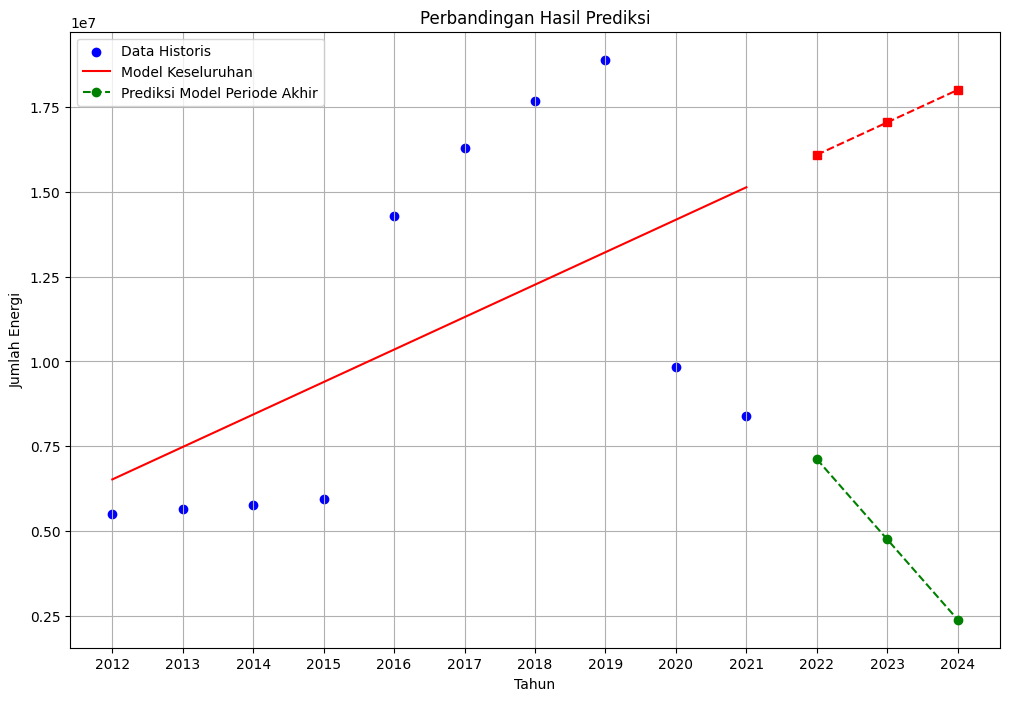

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(df['Tahun'], df['Jumlah'], color='blue', label='Data Historis')
plt.plot(df['Tahun'], model.predict(df['Tahun'].values.reshape(-1, 1)), color='red', linestyle='-', label='Model Keseluruhan')
plt.plot([2022, 2023, 2024], prediksi_jumlah, marker='s', linestyle='--', color='red')
plt.plot([2022, 2023, 2024], prediksi_periode_akhir, marker='o', linestyle='--', color='green', label='Prediksi Model Periode Akhir')
plt.title('Perbandingan Hasil Prediksi')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Energi')
plt.grid(True)
plt.xticks(list(df['Tahun']) + [2022, 2023, 2024])
plt.legend()
plt.show()